In [50]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms, models, datasets
from torchvision.utils import make_grid 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os
from PIL import Image
from IPython.display import display


import warnings
warnings.filterwarnings('ignore')

In [63]:
train_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
                      transforms.Normalize([0.485,0.456,.406],
                        [0.229,.224,.225])
                    
]
)


test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
                      transforms.Normalize([0.485,0.456,.406],
                        [0.229,.224,.225])
                    
]
)


In [3]:
root = '../CNN_project/CATS_DOGS'

train_data = datasets.ImageFolder(os.path.join(root,'train'), transform = train_transform)
test_data = datasets.ImageFolder(os.path.join(root,'test'), transform = test_transform)

torch.manual_seed(50)
train_loader = DataLoader(train_data,batch_size=10,shuffle=True)
test_loader = DataLoader(test_data,batch_size=10,shuffle=True)



In [25]:
os.path.join(root,'test')

'../CNN_project/CATS_DOGS/test'

In [4]:
class_names = train_data.classes

In [5]:
len(train_data)

18747

In [6]:
len(test_data)

6251

## Display a batch of images

Label: [0 1 0 1 1 1 0 1 1 0]
Class: CAT DOG CAT DOG DOG DOG CAT DOG DOG CAT


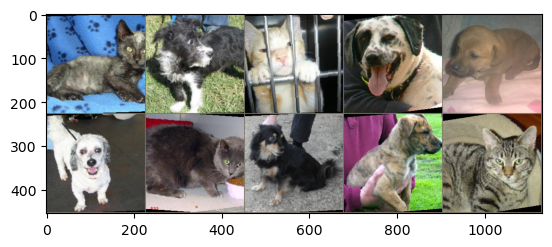

In [7]:
for images, labels in train_loader:
    break


print('Label:', labels.numpy())
print('Class:', *np.array([class_names[i] for i in labels]))

im = make_grid(images, nrow=5)

inv_normalize = transforms.Normalize(
    mean = [-0.485/0.229,-0.456/.224,-.406/0.225],
    std = [1/.229,1/.224,1/.225]
)

im_inv = inv_normalize(im)

plt.imshow(np.transpose(im_inv.numpy(),(1,2,0))) #reorder the axes to H,W,C)
plt.show()

### Define the Model

In [8]:
class ConvolutionalNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,6,3,1)
        self.conv2 = nn.Conv2d(6,16,3,1)
        self.fc1 = nn.Linear(54*54*16,120)
        self.fc2 = nn.Linear(120,84)
        self.fc3 = nn.Linear(84,2)

    def forward(self,X):
        X = F.relu(self.conv1(X))
        X = F.max_pool2d(X,2,2)
        X = F.relu(self.conv2(X))
        X = F.max_pool2d(X,2,2)
        X = X.view(-1,54*54*16)
        X = F.relu(self.fc1(X))
        X = F.relu(self.fc2(X))
        X = self.fc3(X)

        return F.log_softmax(X,dim=1)

In [9]:
(((224-2)/2)-2)/2

54.5

In [10]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

In [11]:
device

device(type='mps')

### Instantiate the Model, define loss, and optimization functions/


In [12]:
torch.manual_seed(50)
CNNmodel = ConvolutionalNetwork()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(CNNmodel.parameters(), lr=0.001)
CNNmodel

ConvolutionalNetwork(
  (conv1): Conv2d(3, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=46656, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=2, bias=True)
)

### Trainable Parameters

In [13]:
params = [p.numel() for p in CNNmodel.parameters() if p.requires_grad]
for item in params:
    print(f'{item:>8}')

     162
       6
     864
      16
 5598720
     120
   10080
      84
     168
       2


In [14]:
sum(params)

5610222

### Train the Model

In [15]:
import time

start_time = time.time()

epochs = 20

max_trn_batch = 800
max_tst_batch = 300

train_losses = []
test_losses = []
train_correct = []
test_correct = []

for i in range(epochs):
    trn_corr = 0
    tst_corr = 0
    for b, (X_train,y_train) in enumerate(train_loader):

        if b == max_trn_batch:
            break
        b = b+1

        #Apply the model
        y_pred = CNNmodel(X_train)
        loss = criterion(y_pred,y_train)

        predicted = torch.max(y_pred.data,1)[1]
        batch_corr = (predicted == y_train).sum()
        trn_corr += batch_corr

        #update the parameters
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if b%200 == 0:
            print(f"Epoch: {i:2} batch: {b:4} [{10*b:6}/8000] loss: {loss.item(): 10.8f} accuracy: {trn_corr.item()*100/(10*b) : 7.3f}%")
    train_losses.append(loss)
    train_correct.append(trn_corr)

    #Run the test batches
    with torch.no_grad():
        for b, (X_test, y_test) in enumerate(test_loader):
            if b == max_tst_batch:
                break

            y_val = CNNmodel(X_test)

            predicted = torch.max(y_val.data,1)[1]
            tst_corr += (predicted == y_test).sum()
    loss = criterion(y_val,y_test)
    test_losses.append(loss)
    test_correct.append(tst_corr)

print(f"\n\nDuration : {time.time() - start_time} seconds")

Epoch:  0 batch:  200 [  2000/8000] loss:  0.69770956 accuracy:  54.100%
Epoch:  0 batch:  400 [  4000/8000] loss:  0.72726125 accuracy:  57.225%
Epoch:  0 batch:  600 [  6000/8000] loss:  0.72983283 accuracy:  58.983%
Epoch:  0 batch:  800 [  8000/8000] loss:  0.58889169 accuracy:  60.663%
Epoch:  1 batch:  200 [  2000/8000] loss:  0.67477757 accuracy:  67.150%
Epoch:  1 batch:  400 [  4000/8000] loss:  0.49074793 accuracy:  68.825%
Epoch:  1 batch:  600 [  6000/8000] loss:  0.55817032 accuracy:  69.750%
Epoch:  1 batch:  800 [  8000/8000] loss:  0.35815710 accuracy:  69.888%
Epoch:  2 batch:  200 [  2000/8000] loss:  0.32585174 accuracy:  72.650%
Epoch:  2 batch:  400 [  4000/8000] loss:  0.81611836 accuracy:  72.450%
Epoch:  2 batch:  600 [  6000/8000] loss:  0.33665600 accuracy:  72.817%
Epoch:  2 batch:  800 [  8000/8000] loss:  0.33765867 accuracy:  73.362%
Epoch:  3 batch:  200 [  2000/8000] loss:  0.27886319 accuracy:  74.300%
Epoch:  3 batch:  400 [  4000/8000] loss:  0.213519

In [16]:
#save the trained model

torch.save(CNNmodel.state_dict(),'CustomerCNNModel.pt')

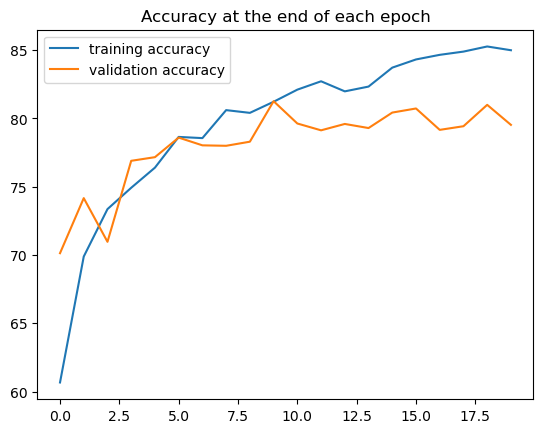

In [17]:
plt.plot([t/80 for t in train_correct],label='training accuracy')
plt.plot([t/30 for t in test_correct],label='validation accuracy')
plt.title('Accuracy at the end of each epoch')
plt.legend()
plt.show()

### Pretrainel model provided by TorchVision

In [18]:
AlexNet = models.alexnet(pretrained=True)
AlexNet

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [19]:
#Freezing feature parameters

for param in AlexNet.parameters():
    param.requires_grad = True

In [20]:
torch.manual_seed(50)
AlexNet.classifier = nn.Sequential(nn.Linear(9216,1024),
                                   nn.ReLU(),
                                   nn.Dropout(0.4),
                                   nn.Linear(1024,2),
                                   nn.LogSoftmax(dim=1))

AlexNet

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Linear(in_features=9216, out_features=1024, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, 

In [21]:
#These are the trainable parameters

params = [p.numel() for p in AlexNet.parameters() if p.requires_grad]
for item in params:
    print(f'{item:>8}')

   23232
      64
  307200
     192
  663552
     384
  884736
     256
  589824
     256
 9437184
    1024
    2048
       2


In [22]:
torch.manual_seed(50)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(AlexNet.classifier.parameters(), lr=0.001)


In [23]:
#train the model

import time

start_time = time.time()

epochs = 10

max_trn_batch = 800
max_tst_batch = 300

train_losses = []
test_losses = []
train_correct = []
test_correct = []

for i in range(epochs):
    trn_corr = 0
    tst_corr = 0
    for b, (X_train,y_train) in enumerate(train_loader):

        if b == max_trn_batch:
            break
        b = b+1

        #Apply the model
        y_pred = AlexNet(X_train)
        loss = criterion(y_pred,y_train)

        predicted = torch.max(y_pred.data,1)[1]
        batch_corr = (predicted == y_train).sum()
        trn_corr += batch_corr

        #update the parameters
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if b%200 == 0:
            print(f"Epoch: {i:2} batch: {b:4} [{10*b:6}/8000] loss: {loss.item(): 10.8f} accuracy: {trn_corr.item()*100/(10*b) : 7.3f}%")
    train_losses.append(loss)
    train_correct.append(trn_corr)

    #Run the test batches
    with torch.no_grad():
        for b, (X_test, y_test) in enumerate(test_loader):
            if b == max_tst_batch:
                break

            y_val = CNNmodel(X_test)

            predicted = torch.max(y_val.data,1)[1]
            tst_corr += (predicted == y_test).sum()
    loss = criterion(y_val,y_test)
    test_losses.append(loss)
    test_correct.append(tst_corr)

print(f"\n\nDuration : {time.time() - start_time} seconds")

Epoch:  0 batch:  200 [  2000/8000] loss:  0.13709548 accuracy:  88.100%
Epoch:  0 batch:  400 [  4000/8000] loss:  0.09158725 accuracy:  90.450%
Epoch:  0 batch:  600 [  6000/8000] loss:  0.09964542 accuracy:  91.433%
Epoch:  0 batch:  800 [  8000/8000] loss:  0.01282424 accuracy:  92.200%
Epoch:  1 batch:  200 [  2000/8000] loss:  0.00001451 accuracy:  94.350%
Epoch:  1 batch:  400 [  4000/8000] loss:  0.00040533 accuracy:  93.950%
Epoch:  1 batch:  600 [  6000/8000] loss:  0.00660576 accuracy:  93.967%
Epoch:  1 batch:  800 [  8000/8000] loss:  0.09250081 accuracy:  94.138%
Epoch:  2 batch:  200 [  2000/8000] loss:  0.00498213 accuracy:  94.450%
Epoch:  2 batch:  400 [  4000/8000] loss:  0.05566433 accuracy:  94.325%
Epoch:  2 batch:  600 [  6000/8000] loss:  0.05394670 accuracy:  94.250%
Epoch:  2 batch:  800 [  8000/8000] loss:  0.00531999 accuracy:  94.300%
Epoch:  3 batch:  200 [  2000/8000] loss:  0.05717648 accuracy:  95.450%
Epoch:  3 batch:  400 [  4000/8000] loss:  0.139655

### Run a new image through the model

In [26]:
len(test_data)

6251

In [42]:
test_data[i]

(tensor([[[2.2489, 2.2318, 2.1975,  ..., 2.2489, 2.2318, 2.2318],
          [2.2489, 2.2318, 2.2147,  ..., 2.2489, 2.2318, 2.2318],
          [2.2489, 2.2318, 2.2147,  ..., 2.2489, 2.2318, 2.2318],
          ...,
          [0.2967, 0.3309, 0.3994,  ..., 1.2043, 1.2385, 1.2557],
          [0.2967, 0.3309, 0.3823,  ..., 1.2043, 1.2385, 1.2385],
          [0.2967, 0.3138, 0.3652,  ..., 1.1872, 1.2214, 1.2214]],
 
         [[2.4286, 2.4111, 2.3761,  ..., 2.3761, 2.4111, 2.4111],
          [2.4286, 2.4286, 2.3936,  ..., 2.3936, 2.4111, 2.4111],
          [2.4286, 2.4286, 2.3936,  ..., 2.3936, 2.4111, 2.4111],
          ...,
          [0.4153, 0.4503, 0.5378,  ..., 1.3957, 1.4132, 1.4132],
          [0.4153, 0.4328, 0.5203,  ..., 1.3957, 1.3957, 1.3957],
          [0.3978, 0.4153, 0.4853,  ..., 1.3957, 1.3782, 1.3782]],
 
         [[2.5703, 2.5529, 2.5180,  ..., 2.5529, 2.5703, 2.5877],
          [2.5703, 2.5529, 2.5354,  ..., 2.5703, 2.5877, 2.6051],
          [2.5703, 2.5529, 2.5354,  ...,

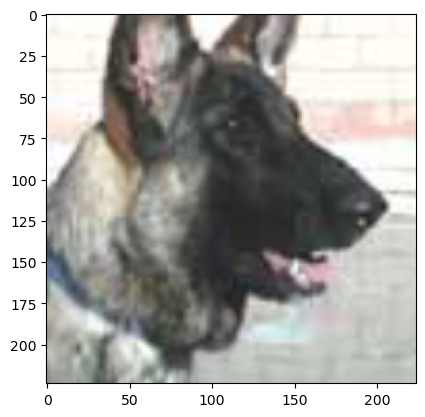

In [54]:
i = 6250

im = inv_normalize(test_data[i][0])
plt.imshow(np.transpose(im.numpy(),(1,2,0)))
plt.show()

In [55]:
test_data[i][0].shape

torch.Size([3, 224, 224])

In [56]:
#CNN model prediction

CNNmodel.eval()
with torch.no_grad():
    pred = CNNmodel(test_data[i][0].view(1,3,224,224)).argmax()
print(f"predicted class: {pred.item()}{class_names[pred.item()]}") 

predicted class: 0CAT


In [57]:
#Alexnet model prediction

AlexNet.eval()
with torch.no_grad():
    pred = AlexNet(test_data[i][0].view(1,3,224,224)).argmax()
print(f"predicted class: {pred.item()}{class_names[pred.item()]}") 

predicted class: 1DOG


In [74]:
CNNmodel.eval()
with torch.no_grad():
    pred = CNNmodel(im.view(1,3,224,224)).argmax()
print(f"predicted class: {pred.item()}{class_names[pred.item()]}") 

predicted class: 1DOG


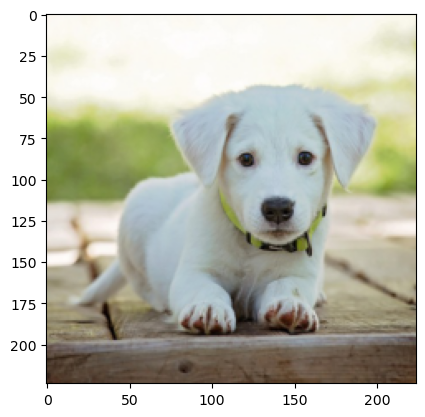

In [76]:
dog = Image.open('puppy.jpg')

dog_norm = test_transform(dog)

im = inv_normalize(dog_norm)
plt.imshow(np.transpose(im.numpy(),(1,2,0)))
plt.show()

In [77]:
im.shape

torch.Size([3, 224, 224])

In [78]:
AlexNet.eval()
with torch.no_grad():
    pred = AlexNet(im.view(1,3,224,224)).argmax()
print(f"predicted class: {pred.item()}{class_names[pred.item()]}") 

predicted class: 1DOG


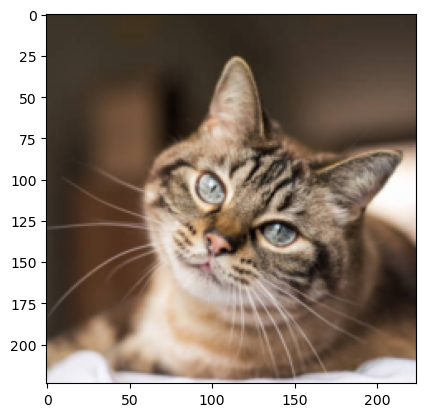

In [79]:
cat = Image.open('cat.jpg')

cat_norm = test_transform(cat)

im = inv_normalize(cat_norm)
plt.imshow(np.transpose(im.numpy(),(1,2,0)))
plt.show()

In [80]:
AlexNet.eval()
with torch.no_grad():
    pred = AlexNet(im.view(1,3,224,224)).argmax()
print(f"predicted class: {pred.item()}{class_names[pred.item()]}") 

predicted class: 0CAT
